In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Bài tập 1:

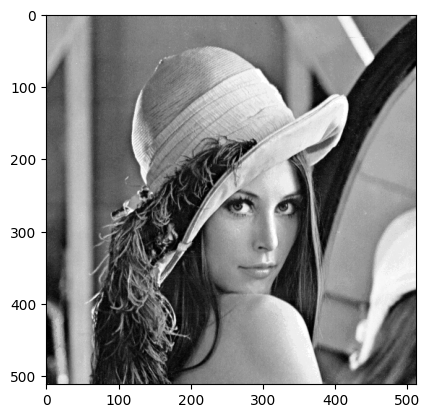

In [4]:
image = cv2.imread('lenna.png', 0)
normalize_image = image.astype(np.float32) / 255.0
plt.imshow(normalize_image, cmap='gray')
plt.show()

Bài tập 2:

In [5]:
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])
sobel_y = sobel_x.T

In [6]:
prewitt_x = np.array([[-1,0,1],
                      [-1,0,1],
                      [-1,0,1]])
prewitt_y = prewitt_x.T

In [7]:
robert_x = np.array([[1,0],
                     [0,-1]])
robert_y = robert_x.T

In [8]:
def convolution(img, kernel, padding):
  img_h, img_w = img.shape
  kernel_h, kernel_w = kernel.shape
  out_img = np.zeros_like(img, dtype = np.float32)
  pad_img = np.pad(img, ((padding, padding), (padding, padding)), mode = 'constant')

  for i in range(img_h):
    for j in range(img_w):
      reagion = pad_img[i:i+kernel_h, j:j+kernel_w]
      out_img[i, j] = np.sum(reagion * kernel)
  return out_img

  out_img = np.zeros_like(img, dtype = np.float32)
  print(pad_img)

In [9]:
sobel_rs_x  = convolution(normalize_image, sobel_x, padding = 1)
sobel_rs_y  = convolution(normalize_image, sobel_y, padding = 1)

In [10]:
prewitt_rs_x  = convolution(normalize_image, prewitt_x, padding = 1)
prewitt_rs_y  = convolution(normalize_image, prewitt_y, padding = 1)

In [11]:
robert_rs_x  = convolution(normalize_image, robert_x, padding = 1)
robert_rs_y  = convolution(normalize_image, robert_y, padding = 1)

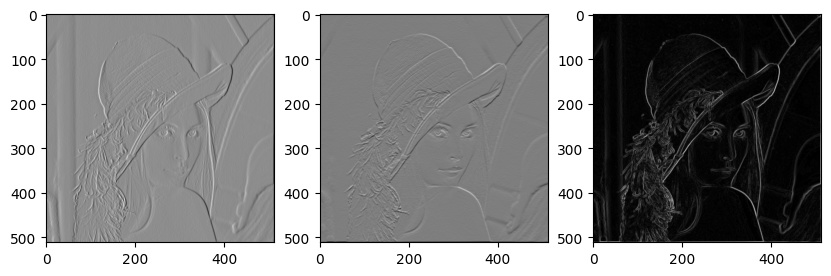

In [12]:
fig, ax = plt.subplots(1, 3, figsize = (10, 5))
ax[0].imshow(sobel_rs_x, cmap = 'gray')
ax[1].imshow(sobel_rs_y, cmap = 'gray')
ax[2].imshow(np.sqrt(sobel_rs_x**2 + sobel_rs_y**2), cmap = 'gray')
plt.show()

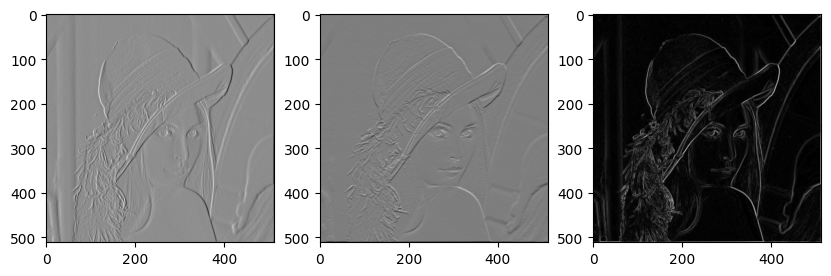

In [13]:
fig, ax = plt.subplots(1, 3, figsize = (10, 5))
ax[0].imshow(prewitt_rs_x, cmap = 'gray')
ax[1].imshow(prewitt_rs_y, cmap = 'gray')
ax[2].imshow(np.sqrt(prewitt_rs_x**2 + prewitt_rs_y**2), cmap = 'gray')
plt.show()

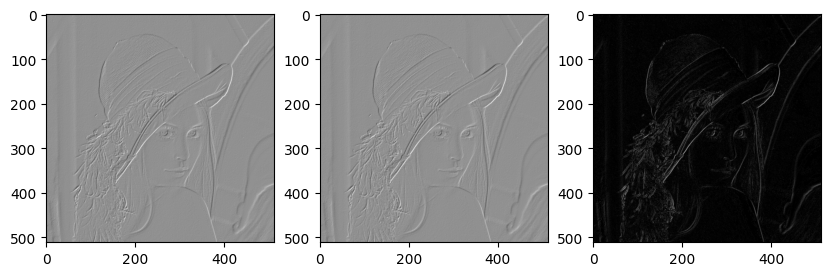

In [14]:
fig, ax = plt.subplots(1, 3, figsize = (10, 5))
ax[0].imshow(robert_rs_x, cmap = 'gray')
ax[1].imshow(robert_rs_y, cmap = 'gray')
ax[2].imshow(np.sqrt(robert_rs_x**2 + robert_rs_y**2), cmap = 'gray')
plt.show()

In [15]:
magnitude_sobel = np.sqrt(sobel_rs_x**2 + sobel_rs_y**2)
direction_sobel = np.arctan(sobel_rs_y, sobel_rs_x)


In [16]:
magnitude_prewitt = np.sqrt(prewitt_rs_x**2 + prewitt_rs_y**2)
direction_prewitt = np.arctan(prewitt_rs_y, prewitt_rs_x)

In [17]:
magnitude_robert = np.sqrt(robert_rs_x**2 + robert_rs_y**2)
direction_robert = np.arctan(robert_rs_y, robert_rs_x)

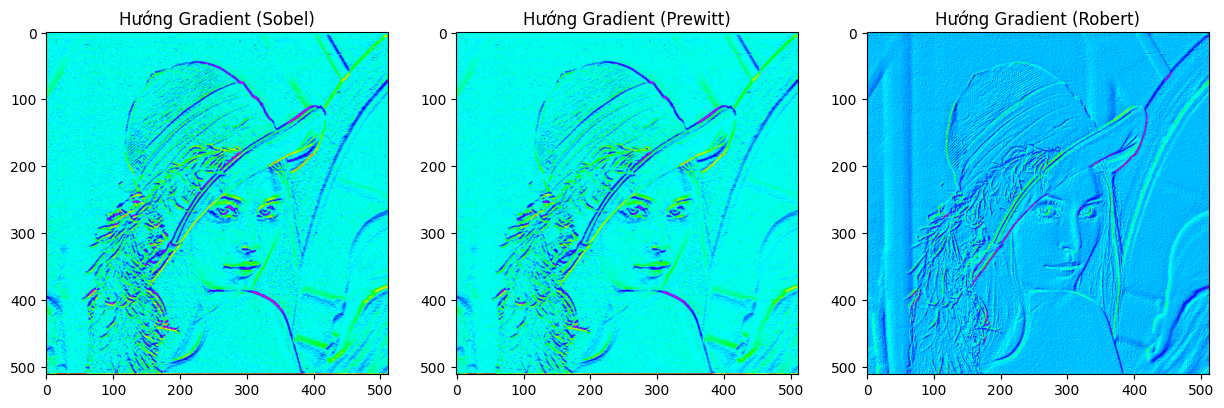

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 hàng, 3 cột

# Hiển thị 3 hình direction
axes[0].imshow(direction_sobel, cmap='hsv')
axes[0].set_title('Hướng Gradient (Sobel)')

axes[1].imshow(direction_prewitt, cmap='hsv')
axes[1].set_title('Hướng Gradient (Prewitt)')

axes[2].imshow(direction_robert, cmap='hsv')
axes[2].set_title('Hướng Gradient (Robert)')

plt.show()

In [19]:
threshold = 0.3
filtered_image = np.where(magnitude_sobel > threshold, 1, 0)

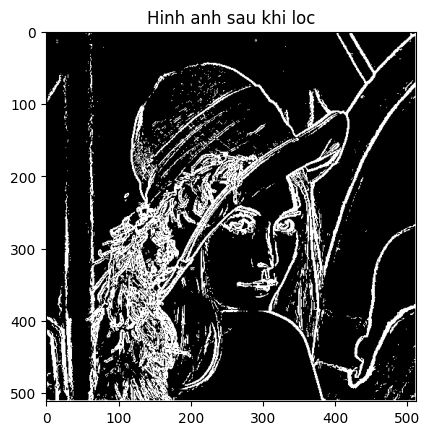

In [22]:
plt.imshow(filtered_image, cmap = 'gray')
plt.title('Hinh anh sau khi loc')
plt.show()